# chrisMain — VarMeanNoise Analysis

Goal: pull stimulus + response data for the `varMeanNoise` protocol, then transfer cell types and STAs from the nearest noise (`SpatialNoise`) chunk via EI matching.

Steps:
1. Find every experiment that ran `varMeanNoise`
2. Pick a date
3. Build the pipeline (StimBlock + ResponseBlock for the protocol, AnalysisChunk for the noise chunk; `create_mea_pipeline` runs the EI-based cluster match automatically)
4. Sanity-check the matching by comparing RFs
5. Pull spike trains as an xarray for downstream analysis

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

/Users/chrischen/opt/anaconda3/envs/retinanalysis/lib/python3.11/site-packages/datajoint/settings.py:979: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


[2026-05-11 23:54:38] DataJoint 2.1.1 connected to root@127.0.0.1:3306


## 1. Find all experiments that ran `varMeanNoise`

`get_datasets_from_protocol_names` does a lowercase substring match against the protocol registry, so `'varmeannoise'` will catch the full Java class name (e.g. `manookinlab.protocols.VarMeanNoise`). After the DB query we filter to only experiments whose sort output is actually present on disk (`ra.ANALYSIS_DIR`).

In [2]:
exp_search = ra.get_datasets_from_protocol_names('AlternatingBackground')

# Filter to experiments that exist on the MEA SSD
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop=True)

print(f'{len(exp_search)} usable datafile(s) found across '
      f'{exp_search.exp_name.nunique()} experiment(s).')
display(exp_search)


Found 1 protocols matching "alternatingbackground":
['edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']



Found 23 experiments, 32 epoch blocks.

28 usable datafile(s) found across 21 experiment(s).


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20221006C,data029,1.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221006C/data029,Eye movement trajectory alternating background,25,41,386,972,54
1,20221123C,data027,2.0,chunk4,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221123C/data027,CC eye movement alt background ndf2.0,30,41,530,1179,69
2,20230214C,data018,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230214C/data018,eye movement alt background ndf 3.0,39,41,781,1484,97
3,20230313C,data017,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data017,eye movement alt background ndf 3.0,42,41,878,1609,108
4,20230313C,data019,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data019,Var Mean Drift Grating ndf 3.0,42,41,879,1611,108
5,20230502C,data018,2.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230502C/data018,ndf 2.0 eye movement alt background,52,41,1077,1855,156
6,20230523C,data013,2.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230523C/data013,Eye movement alt background,56,41,1178,1983,176
7,20230525C,data052,0.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230525C/data052,Eye Movement Alternating Background Photopic,58,41,1220,2041,184
8,20230725C,data036,2.0,chunk4,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230725C/data036,ndf 2 eye movement alt background,65,41,1397,2264,205
9,20231003C,data021,0.5,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20231003C/data021,eye movement alt background,71,41,1516,2416,221


## 2. Pick a date

Set `exp_name` to one of the dates listed above. If that experiment ran `varMeanNoise` more than once (multiple datafiles), pick the specific one you want via `datafile_name` — by default we take the first.

In [3]:
exp_name = exp_search['exp_name'].iloc[0]   # <-- EDIT ME to pick a different date

datafiles_for_exp = exp_search.query('exp_name == @exp_name')['datafile_name'].values
print(f'{exp_name} has varMeanNoise in: {list(datafiles_for_exp)}')

datafile_name = datafiles_for_exp[0]        # <-- EDIT ME if more than one datafile
print(f'Using {exp_name} / {datafile_name}')

# Full summary of the chosen day — useful to see which datafiles are SpatialNoise (candidate chunks)
display(ra.get_exp_summary(exp_name))

20221006C has varMeanNoise in: ['data029']
Using 20221006C / data029


,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
0,20221006C,Mount1,data000,CRF,0.0,chunk1,manookinlab.protocols.ContrastResponseGrating,1.17,1.17,2022-10-06 10:07:17,2022-10-06 10:08:27,20221006C/data000,25,28,361,944,52,3
1,20221006C,Mount1,data001,noise cone,0.0,chunk1,manookinlab.protocols.FastNoise,30.72,33.32,2022-10-06 10:09:53,2022-10-06 10:40:36,20221006C/data001,25,28,362,945,52,1
2,20221006C,Mount1,data002,flashes,0.0,chunk1,manookinlab.protocols.ConeTyperMonitor,2.63,36.72,2022-10-06 10:41:22,2022-10-06 10:44:00,20221006C/data002,25,28,363,946,52,12
3,20221006C,Mount1,data003,DS gratings,0.0,chunk1,manookinlab.protocols.GratingDSOS,19.55,57.57,2022-10-06 10:45:18,2022-10-06 11:04:51,20221006C/data003,25,28,364,947,52,13
4,20221006C,Mount1,data004,oriented bars,0.0,chunk1,manookinlab.protocols.MovingChromaticBar,2.82,65.40,2022-10-06 11:09:52,2022-10-06 11:12:41,20221006C/data004,25,28,365,948,52,8
5,20221006C,Mount1,data005,oriented bars,0.0,chunk1,manookinlab.protocols.MovingChromaticBar,24.23,89.73,2022-10-06 11:12:47,2022-10-06 11:37:01,20221006C/data005,25,28,365,949,52,8
6,20221006C,Mount1,data006,chirp,0.0,chunk1,manookinlab.protocols.ChirpStimulus,2.45,93.10,2022-10-06 11:37:56,2022-10-06 11:40:23,20221006C/data006,25,28,366,950,52,11
7,20221006C,Mount1,data007,natural image flash noise,0.0,chunk1,manookinlab.protocols.NaturalImageFlashPlusNoise,21.35,114.88,2022-10-06 11:40:49,2022-10-06 12:02:10,20221006C/data007,25,28,367,951,52,32
8,20221006C,Mount1,data008,CRF,0.0,chunk1,manookinlab.protocols.ContrastResponseGrating,1.17,117.40,2022-10-06 12:03:31,2022-10-06 12:04:41,20221006C/data008,25,28,368,952,52,3
9,20221006C,Mount1,data009,noise cone,0.0,chunk1,manookinlab.protocols.FastNoise,30.72,148.92,2022-10-06 12:05:29,2022-10-06 12:36:12,20221006C/data009,25,28,369,953,52,1


## 3. Build the pipeline

`create_mea_pipeline` does everything in one shot:
- **StimBlock** — loads stimulus params and frame timing for the `varMeanNoise` datafile.
- **ResponseBlock** — loads spike times from the kilosort output for that datafile.
- **Nearest noise chunk** — auto-resolved from the experiment summary (whatever `SpatialNoise` chunk is closest in time). You can override this with `analysis_chunk_name='chunk2'` etc.
- **AnalysisChunk** — loads STAs, RF params, EIs, ISIs, timecourses, and the classification (cell type) file from the noise chunk.
- **EI-based cluster match** — `cluster_match()` is called internally to align the noise-chunk cell IDs to the protocol cell IDs by EI footprint correlation. After this, the protocol cells carry `noise_id` and `cell_type` columns.

In [4]:
from retinanalysis.config.settings import find_path

# Older experiments are often sorted with kilosort2 (not 2.5). Auto-detect:
exp_sort_dir = find_path('data', exp_name, datafile_name)
available_ss = [d for d in os.listdir(exp_sort_dir) if d.startswith('kilosort')]
ss_version = 'kilosort2.5' if 'kilosort2.5' in available_ss else available_ss[0]

# Auto-discover a typing file in the nearest noise chunk.
# Override `typing_file_name` below if you have a preferred classification file.
from retinanalysis.classes.stim import MEAStimBlock
_tmp_stim = MEAStimBlock(exp_name, datafile_name, verbose=False)
noise_chunk_name = _tmp_stim.nearest_noise_chunk
chunk_dir = find_path('analysis', exp_name, noise_chunk_name, ss_version)
typing_candidates = [f for f in os.listdir(chunk_dir) if f.endswith('.classification.txt')]
typing_file_name = typing_candidates[0]   # <-- EDIT ME to pick a specific classification file

print(f'ss_version: {ss_version}')
print(f'noise chunk: {noise_chunk_name}')
print(f'typing file: {typing_file_name}')
print(f'(other classification files in chunk: {typing_candidates})')

pipeline = ra.create_mea_pipeline(
    exp_name,
    datafile_name,
    ss_version=ss_version,
    typing_file=typing_file_name,
    # analysis_chunk_name=None,   # uncomment + set to override the auto-picked noise chunk
)

stim_block      = pipeline.stim
response_block  = pipeline.resp
analysis_chunk  = pipeline.analysis_chunk

print(f'\nNoise chunk used: {analysis_chunk.chunk_name}')
print(f'Cells in noise chunk: {len(analysis_chunk.cell_ids)}')
print(f'Cells in protocol datafile: {len(response_block.cell_ids)}')
print(f'Cells matched by EI: {len(pipeline.match_dict)}')

ss_version: kilosort2
noise chunk: chunk3
typing file: chris.kilosort2.classification.txt
(other classification files in chunk: ['chris.kilosort2.classification.txt'])


Initializing StimBlock for 20221006C block 972


For Rig C 20221006C:
{'disp_type': 'OLED', 'mu_per_pixel': 3.8, 'n_ht': 600, 'n_wt': 800, 'mean_frame_rate': 60.31807657, 'stage_frame_rate': np.float64(60.0)}


Nearest noise chunk for data029 is chunk3 with distance 17 minutes.



Initializing ResponseBlock for 20221006C block 972
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


...

Using chunk3 for AnalysisChunk

Loading VCD from /Volumes/data/analysis/20221006C/chunk3/kilosort2 ...


VCD loaded with 1054 cells.




Loaded spatial maps for channels [0, 2] and 1054 cells of shape (76, 100, 2)
Spatial maps have been padded to align with RF parameters.



Cluster matching 20221006C chunk3 with EyeMovementTrajectoryAlternatingBackground ...
41.56% matched, 58.44% unmatched.

Using chris.kilosort2.classification.txt for classification.




Noise chunk used: chunk3
Cells in noise chunk: 1054
Cells in protocol datafile: 1131
Cells matched by EI: 438


## 4. Sanity-check the EI match

Plot the RFs the protocol cells inherited (via the match) next to the native RFs from the noise chunk. If matching is good, the two mosaics should look nearly identical per cell type.

Cell-type counts (matched protocol cells):
cell_type
Unmatched    693
Unknown      438
Name: count, dtype: int64

Using cell_types: ['Unknown']


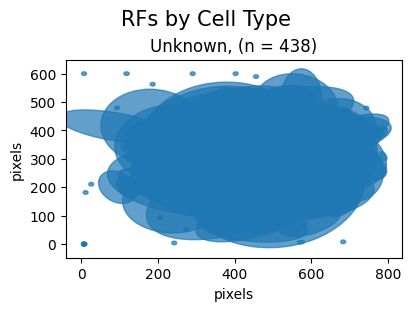

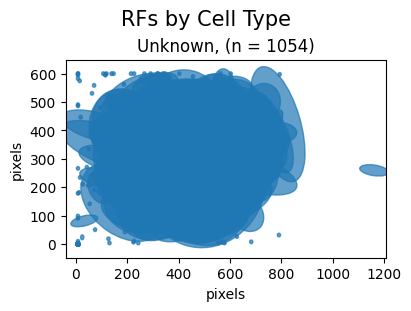

In [5]:
# Auto-detect cell types actually present in this experiment's classification file.
# (The canonical OnP/OffP/etc. labels only apply when the chunk has a fine-grained
# hand-classification. Many older experiments only get 'Unknown' = matched but untyped.)
type_counts = response_block.df_spike_times['cell_type'].value_counts()
print('Cell-type counts (matched protocol cells):')
print(type_counts.head(20))

# Drop only 'Unmatched' (no EI twin). Keep 'Unknown' so we can still see matched cells.
cell_types = [t for t, n in type_counts.items() if n >= 3 and t != 'Unmatched']
print(f'\nUsing cell_types: {cell_types}')

if len(cell_types) == 0:
    print('No cell types with >=3 matched cells — skipping RF plots.')
else:
    try:
        _ = pipeline.plot_rfs(cell_types=cell_types, minimum_n=3, b_zoom=True)
    except Exception as e:
        print(f'pipeline.plot_rfs skipped: {e}')
    try:
        _ = analysis_chunk.plot_rfs(
            cell_types=cell_types, minimum_n=3, b_zoom=True,
            typing_file=typing_file_name,
        )
    except Exception as e:
        print(f'analysis_chunk.plot_rfs skipped: {e}')

## 5. Inspect stimulus parameters

`stim_block.df_epochs` has one row per epoch with the params that varied (e.g. mean, variance, seed). `d_epoch_block_params` has the block-level params (preTime/stimTime/tailTime, etc.).

In [6]:
display(stim_block.df_epochs.head())

print('\nEpoch-block params:')
for k, v in stim_block.d_epoch_block_params.items():
    print(f'  {k}: {v}')

,epoch_index,currentImageName,backgroundIntensity,currentBackgroundScale,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,00152,0.009608,0.1,20221006C,data029,Eye movement trajectory alternating background,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 83.0, 99.0, 116....","{'D': 5.0, 'NDF': 1.0, 'amp': 'Amp1', 'ndfs': ...",20221006C/data029,30000.0,30000.0,0.0,25,386,972,41,40169
1,1,00152,0.960779,10.0,20221006C,data029,Eye movement trajectory alternating background,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 50.0, 66.0, 83.0, 99.0, 116....","{'D': 5.0, 'NDF': 1.0, 'amp': 'Amp1', 'ndfs': ...",20221006C/data029,30000.0,30000.0,0.0,25,386,972,41,40170
2,2,00459,0.035755,0.1,20221006C,data029,Eye movement trajectory alternating background,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 50.0, 66.0, 83.0, 99.0, 116....","{'D': 5.0, 'NDF': 1.0, 'amp': 'Amp1', 'ndfs': ...",20221006C/data029,30000.0,30000.0,0.0,25,386,972,41,40171
3,3,00459,3.575503,10.0,20221006C,data029,Eye movement trajectory alternating background,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 50.0, 66.0, 83.0, 99.0, 116....","{'D': 5.0, 'NDF': 1.0, 'amp': 'Amp1', 'ndfs': ...",20221006C/data029,30000.0,30000.0,0.0,25,386,972,41,40172
4,4,01151,0.020199,0.1,20221006C,data029,Eye movement trajectory alternating background,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 50.0, 66.0, 83.0, 99.0, 116....","{'D': 5.0, 'NDF': 1.0, 'amp': 'Amp1', 'ndfs': ...",20221006C/data029,30000.0,30000.0,0.0,25,386,972,41,40173



Epoch-block params:
  D: 5.0
  amp: Amp1
  preTime: 30000.0
  stimTime: 30000.0
  tailTime: 0.0
  patchMean: all
  randomSeed: 1.0
  sampleRate: 1000.0
  onlineAnalysis: none
  backgroundScale: [0.1, 10.0]
  apertureDiameter: 0.0
  numberOfAverages: 30


## 6. Pull spike times across cells

`get_spike_xarr` returns an xarray with dims `(cell_id, epoch)`, each entry an array of spike times in ms. Coords include `cell_type`, so you can `.sel`/`.where` by type. Filtering by `cell_types` keeps only EI-matched, typed cells.

In [7]:
if len(cell_types) == 0:
    print('No usable cell types — skipping spike xarray.')
    spike_times = None
else:
    spike_times = ra.get_spike_xarr(response_block, cell_types=cell_types, minimum_n=3)
    spike_counts = xr.apply_ufunc(len, spike_times, vectorize=True)

    print(f'Spike xarray shape: {dict(spike_times.sizes)}')
    print(f'Cell types present: {sorted(np.unique(spike_times.cell_type.values))}')

    # Baseline (pre-stim) counts per cell x epoch
    pre_time = stim_block.d_epoch_block_params['preTime']

    def baseline_count(arr, pre_time):
        return int(np.sum(np.asarray(arr) < pre_time))

    baseline_counts = xr.apply_ufunc(
        baseline_count, spike_times,
        kwargs={'pre_time': pre_time}, vectorize=True,
    )

    display(spike_counts)

Spike xarray shape: {'cell_id': 438, 'epoch': 30}
Cell types present: [np.str_('Unknown')]


<xarray.DataArray (cell_id: 438, epoch: 30)> Size: 105kB
array([[177,  17, 153, ...,  26, 226,  15],
       [490, 262, 297, ..., 177, 431, 176],
       [  3,   3,   3, ...,   4,   0,   4],
       ...,
       [107, 129, 140, ...,  63,  18,   7],
       [297,  82, 203, ...,  56, 131,   4],
       [ 64, 119,  97, ..., 146,  55, 108]], shape=(438, 30))
Coordinates:
  * cell_id    (cell_id) int64 4kB 1 5 9 11 12 14 ... 1135 1141 1143 1145 1149
    cell_type  (cell_id) <U7 12kB 'Unknown' 'Unknown' ... 'Unknown' 'Unknown'
    noise_id   (cell_id) int64 4kB 1 5 9 11 12 14 ... 1135 1141 1143 1145 1149
  * epoch      (epoch) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29

## 7. Access STA + EI for a specific cell

After matching, you can look up any protocol cell's noise-chunk twin and grab its STA / EI / timecourse from `analysis_chunk`.

- `pipeline.match_dict[noise_cell_id] = protocol_cell_id` (noise → protocol)
- `analysis_chunk.d_EIs[noise_cell_id]` — electrical image
- `analysis_chunk.d_timecourses[noise_cell_id]` — RGB timecourses
- `analysis_chunk.d_ISIs[noise_cell_id]` — ISI distribution

Noise cell 1  <->  Protocol cell 1
EI shape: (512, 201)
Timecourse channels: ['red', 'green', 'blue']


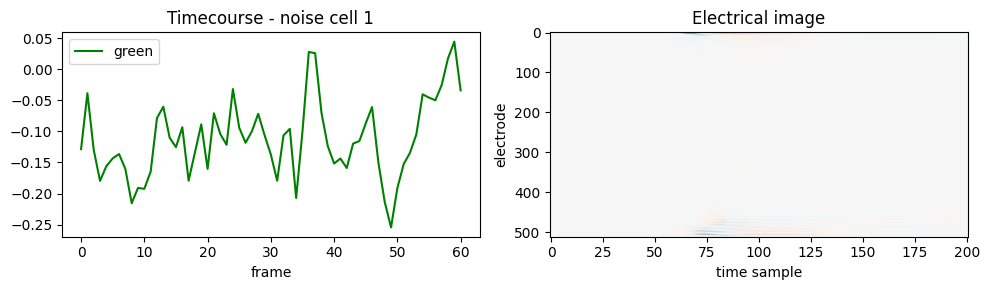

In [8]:
# Example: grab the first matched cell
noise_id, protocol_id = next(iter(pipeline.match_dict.items()))
print(f'Noise cell {noise_id}  <->  Protocol cell {protocol_id}')

ei = analysis_chunk.d_EIs[noise_id]
tc = analysis_chunk.d_timecourses[noise_id]

print(f'EI shape: {ei.shape}')
print(f'Timecourse channels: {list(tc.keys())}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(tc['green'], color='g', label='green')
if not np.allclose(tc['red'], tc['green']):
    axes[0].plot(tc['red'], color='r', label='red')
    axes[0].plot(tc['blue'], color='b', label='blue')
axes[0].set_title(f'Timecourse - noise cell {noise_id}')
axes[0].set_xlabel('frame'); axes[0].legend()

# EI is (n_electrodes, n_samples) — show as a heatmap
axes[1].imshow(ei, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(ei).max(), vmax=np.abs(ei).max())
axes[1].set_title('Electrical image')
axes[1].set_xlabel('time sample'); axes[1].set_ylabel('electrode')
plt.tight_layout()